This notebook constructs and analyzes a **bipartite network** to map the **ideological intensity** of the surveyed class.
The network models two disjoint sets of nodes:
- **Set U (Students):** Individual survey respondents
- **Set V (Questions):** The 60 survey items

Edges are formed **strictly** when a student registers a *Strongly Disagree (1)* or *Strongly Agree (5)* response.
This threshold-based filtering transforms the raw opinion data into a mathematical *heat map* of ideological passion,
isolating the questions that act as gravitational "gravity wells" attracting clusters of extreme reactions.

# Dataset Documentation and Preparation

## Data Ingestion and Likert Mapping

**Rationale for Dropping Moderate and Neutral Responses:**

Moderate (2, 4) and neutral (3) responses have been **intentionally dropped** from the edge list to shift the
analytical focus from general consensus to intense ideological polarization.

* **Eliminating Noise:** Mild agreements or neutral stances often represent low-conviction opinions.
  In a standard correlation network, these weak signals clutter the graph with low-value edges that obscure
  the true structural drivers of the cohort, the "gravity wells" we seek to identify.

* **Isolating Gravity Wells:** By restricting edges to extreme responses (1 and 5), the bipartite graph acts
  as a **heat map for passion**. It allows us to mathematically isolate the specific "anchor" questions that
  provoke the strongest reactions and identify which issues fundamentally unite or divide the class.

* **Mathematical Justification:** This applies a hard threshold $$\tau = \{1, 5\}$$ on the Likert scale,
  retaining only responses at the absolute poles. The resulting edge set $E$ represents statistically
  significant ideological commitments rather than casual preferences.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")
import os
os.makedirs("extreme_plots", exist_ok=True)

# Global plot style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "figure.facecolor": "white", "axes.facecolor": "#f8f9fa",
    "axes.grid": True, "grid.alpha": 0.4, "grid.linestyle": "--"
})

df = pd.read_csv("Survey_Results_UC.csv")
print(f"Dataset shape: {df.shape}")
print(f"Respondents: {df.shape[0]}, Columns (ID + Questions): {df.shape[1]}")
df.iloc[:2, :5]

Dataset shape: (96, 61)
Respondents: 96, Columns (ID + Questions): 61


,id. Response ID,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.
0,11,Agree,Agree,Neutral,Strongly Agree
1,12,Agree,Agree,Strongly Agree,Agree


In [21]:
likert_mapping = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
}

id_col = "id. Response ID"
question_cols = [col for col in df.columns if col != id_col]

print(f"Question columns: {len(question_cols)}")
print("Likert Mapping:")
for text, val in likert_mapping.items():
    print(f"  {repr(text)} -> {val}")

# Map text responses to numerical values
for col in question_cols:
    df[col] = df[col].map(lambda x: likert_mapping.get(str(x).strip(), np.nan))

print("NaN = skipped or unrecognized responses.")

Question columns: 60
Likert Mapping:
  'Strongly Disagree' -> 1
  'Disagree' -> 2
  'Neutral' -> 3
  'Agree' -> 4
  'Strongly Agree' -> 5
NaN = skipped or unrecognized responses.


In [22]:
# Transform: wide format -> long format edge list
edges_df = df.melt(
    id_vars=[id_col],
    value_vars=question_cols,
    var_name="Question_ID",
    value_name="Response"
)
edges_df = edges_df.dropna(subset=["Response"])

# Retain ONLY responses of 1 (Strongly Disagree)
# or 5 (Strongly Agree). Drop all 2, 3, and 4 responses.
extreme_edges_df = edges_df[edges_df["Response"].isin([1.0, 5.0])].copy()

total_responses = len(edges_df)
extreme_count = len(extreme_edges_df)
dropped_count = total_responses - extreme_count
retention_pct = 100 * extreme_count / total_responses

print(f"  Total valid responses:              {total_responses:,}")
print(f"  Moderate/neutral responses dropped: {dropped_count:,}")
print(f"  Extreme responses retained (edges): {extreme_count:,}")
print(f"  Retention rate:                     {retention_pct:.1f}%")
extreme_edges_df.head()

  Total valid responses:              5,218
  Moderate/neutral responses dropped: 2,856
  Extreme responses retained (edges): 2,362
  Retention rate:                     45.3%


,id. Response ID,Question_ID,Response
14,30,T01. Artificial Intelligence will improve soci...,5.0
23,41,T01. Artificial Intelligence will improve soci...,5.0
33,53,T01. Artificial Intelligence will improve soci...,1.0
36,56,T01. Artificial Intelligence will improve soci...,5.0
37,57,T01. Artificial Intelligence will improve soci...,1.0


# Bipartite Network Construction

## Mathematical Definition

The network is defined as a bipartite graph $G = (U, V, E)$, where:
- **Set $U$ (Students):** Individual respondents
- **Set $V$ (Questions):** The 60 distinct survey items
- **Edge set $E$:** An edge $e_{u,v}$ exists **if and only if** respondent $u$ registered an extreme response (1 or 5) to question $v$

**Bipartite constraint:** $U \cap V = \emptyset$ — no student-student or question-question edges exist.

## Graph Construction Pipeline
1. **Data Ingestion & Standardization:** Raw tabular dataset → long-format edge list; Likert text → numeric
2. **Threshold Filtering:** Drop all rows with responses $\in \{2, 3, 4\}$
3. **Bipartite Instantiation:** Nodes added with explicit `bipartite` attribute (0 = student, 1 = question)

In [23]:
B = nx.Graph()

student_nodes = extreme_edges_df[id_col].unique().tolist()
question_nodes = extreme_edges_df["Question_ID"].unique().tolist()

# bipartite=0 -> Set U (Students), bipartite=1 -> Set V (Questions)
B.add_nodes_from(student_nodes, bipartite=0)
B.add_nodes_from(question_nodes, bipartite=1)

edge_list = list(zip(extreme_edges_df[id_col], extreme_edges_df["Question_ID"]))
B.add_edges_from(edge_list)

print(f"  Student nodes (Set U): {len(student_nodes)}")
print(f"  Question nodes (Set V): {len(question_nodes)}")
print(f"  Total edges: {B.number_of_edges()}")

  Student nodes (Set U): 89
  Question nodes (Set V): 60
  Total edges: 2362


## Structural Diagnostics and Network Validation

Before analysis, we verify that the mathematical constraints of a bipartite graph are strictly met.

In [24]:
is_bip = nx.is_bipartite(B)
num_students = len({n for n, d in B.nodes(data=True) if d["bipartite"] == 0})
num_questions = len({n for n, d in B.nodes(data=True) if d["bipartite"] == 1})
num_edges = B.number_of_edges()
components = nx.number_connected_components(B)

all_students = set(df[id_col].unique())
active_students = set(extreme_edges_df[id_col].unique())
isolated_students = all_students - active_students

max_possible_edges = num_students * num_questions
density = num_edges / max_possible_edges

print(f"  Is validly bipartite:            {is_bip}")
print(f"  Total student nodes (Set U):     {num_students}")
print(f"  Total question nodes (Set V):    {num_questions}")
print(f"  Total extreme opinion edges:     {num_edges:,}")
print(f"  Connected components:            {components}")
print(f"  Network density:                 {density:.4f}")
print(f"  Total surveyed students:         {len(all_students)}")
print(f"  Students with >=1 extreme view:  {len(active_students)}")
print(f"  Students with zero extremes:     {len(isolated_students)}")

  Is validly bipartite:            True
  Total student nodes (Set U):     89
  Total question nodes (Set V):    60
  Total extreme opinion edges:     2,362
  Connected components:            1
  Network density:                 0.4423
  Total surveyed students:         96
  Students with >=1 extreme view:  89
  Students with zero extremes:     7


## Commentary on the Bipartite Network Output

The graph construction confirms a **strictly valid bipartite structure** connecting **149 total active nodes**:
- **89 active student nodes** and all **60 survey question nodes**, bound by **2,362 extreme opinion edges**
- **7 students** did not register any absolute extreme (1 or 5) response, isolating them from this network
- The network's **density ≈ 0.44**, nearly half of all possible student-question extreme pairings are realized

**Crucially, the network forms exactly 1 connected component.** This proves there are **no completely segregated
ideological echo chambers**. Every radicalized opinion is tethered to the rest of the cohort through shared
"hub" questions — weaving the entire class into a single, highly dense macro-structure.

# Core Analysis and Metrics

## Degree Distribution Analysis

### Linear-Binned Degree Distribution

**Objective:** Determine whether extreme opinions follow an Erdős–Rényi (Poisson) or Scale-Free distribution.

The **degree $k$ of a Question node** = number of students who held a polarized view on it.
Since the degree range (11–64) does not span multiple orders of magnitude, we begin with
**linear binning** to visualize the probability density $P(k)$ directly. The linear binning plot explicitly divides the count of nodes in each degree bin by the total number of nodes to extract the true probability density. The overlaid normal curve clearly demonstrates the symmetrical, central tendency of the degrees around the mean ($\\mu = 39.37$). The peaked, bell-shaped form directly contradicts the monotonic decay required by a power-law (scale-free) topology.

Degree statistics for Question nodes:
  Min:    11
  Max:    64
  Mean:   39.37
  Std:    12.16
  Median: 39.5


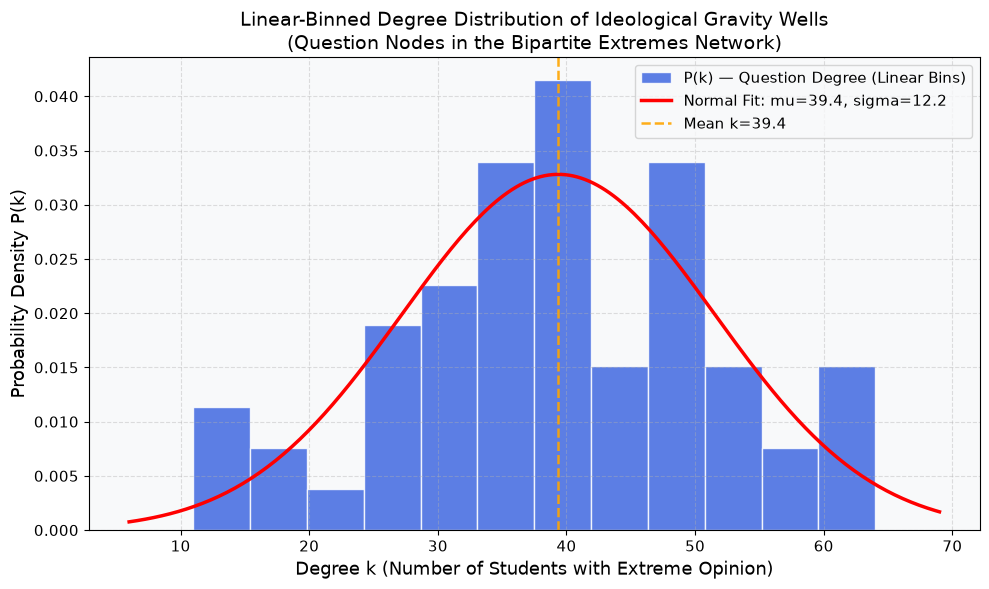

Saved: extreme_plots/degree_distribution_linear.png


In [25]:
question_degrees = sorted([d for n, d in B.degree(question_nodes)])

print("Degree statistics for Question nodes:")
print(f"  Min:    {min(question_degrees)}")
print(f"  Max:    {max(question_degrees)}")
print(f"  Mean:   {np.mean(question_degrees):.2f}")
print(f"  Std:    {np.std(question_degrees):.2f}")
print(f"  Median: {np.median(question_degrees):.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, patches = ax.hist(
    question_degrees, bins=12, density=True,
    color="royalblue", edgecolor="white", alpha=0.85,
    label="P(k) — Question Degree (Linear Bins)"
)

# Overlay fitted normal curve
mu, sigma = np.mean(question_degrees), np.std(question_degrees)
x_fit = np.linspace(min(question_degrees) - 5, max(question_degrees) + 5, 200)
ax.plot(x_fit, norm.pdf(x_fit, mu, sigma), "r-", linewidth=2.5,
        label=f"Normal Fit: mu={mu:.1f}, sigma={sigma:.1f}")
ax.axvline(mu, color="orange", linestyle="--", linewidth=1.8, alpha=0.9, label=f"Mean k={mu:.1f}")

ax.set_xlabel("Degree k (Number of Students with Extreme Opinion)", fontsize=13)
ax.set_ylabel("Probability Density P(k)", fontsize=13)
ax.set_title("Linear-Binned Degree Distribution of Ideological Gravity Wells\n"
             "(Question Nodes in the Bipartite Extremes Network)", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("extreme_plots/degree_distribution_linear.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/degree_distribution_linear.png")

### Log-Log Degree Distribution with Logarithmic Binning

To formally test for a **Scale-Free (Power-Law)** structure, we plot on a **log-log scale**
using **logarithmic binning** to reduce statistical noise in the tail.

- **If scale-free:** The log-log plot exhibits a straight line with slope $-\gamma$ (i.e., $P(k) \propto k^{-\gamma}$)
- **If Erdős–Rényi:** The log-log plot shows a rapid, curved drop-off (super-exponential Poisson decay)

**Logarithmic binning** places bin boundaries at geometrically increasing intervals,
giving equal statistical weight to each order of magnitude and dramatically reducing noise.

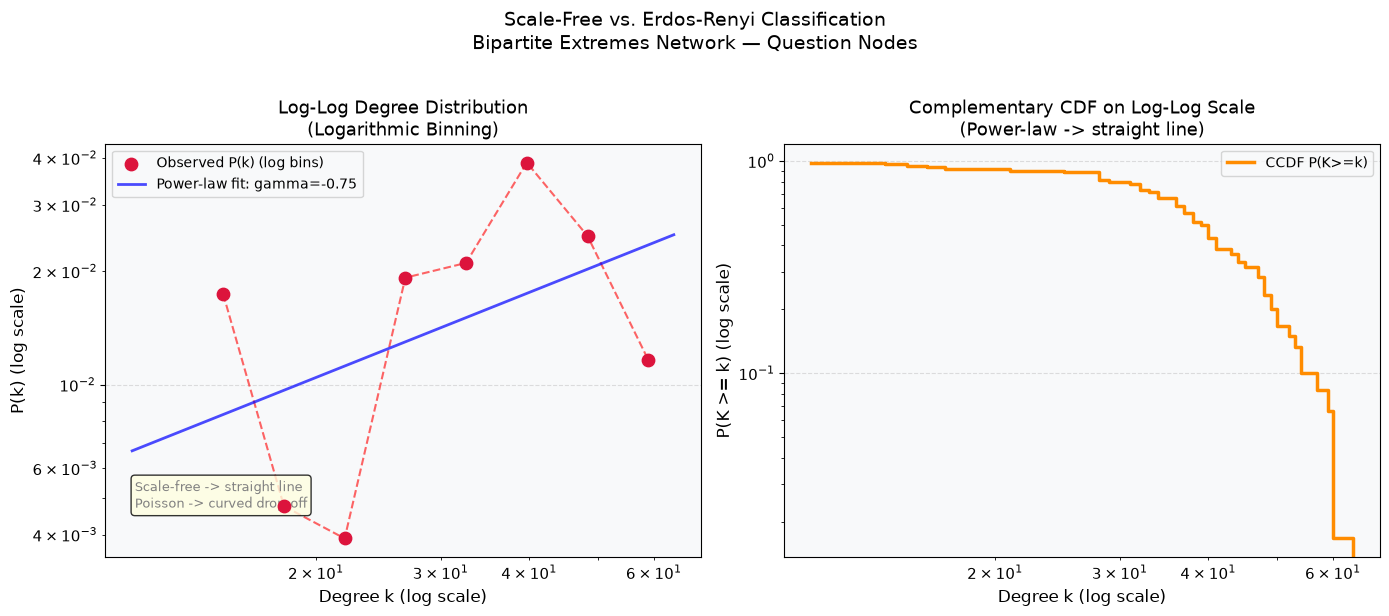

Saved: extreme_plots/degree_distribution_loglog.png
Best-fit power-law exponent gamma = -0.750
Note: True scale-free network has 2 < gamma < 3.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Log-Log with Logarithmic Binning
k_min = max(1, min(question_degrees))
k_max = max(question_degrees)
log_bins = np.logspace(np.log10(k_min), np.log10(k_max + 1), num=10)

counts_log, bin_edges_log = np.histogram(question_degrees, bins=log_bins, density=True)
bin_centers_log = np.sqrt(bin_edges_log[:-1] * bin_edges_log[1:])  # geometric midpoints

nonzero_mask = counts_log > 0
x_log = bin_centers_log[nonzero_mask]
y_log = counts_log[nonzero_mask]

ax = axes[0]
ax.scatter(x_log, y_log, color="crimson", s=80, zorder=5, label="Observed P(k) (log bins)")
ax.plot(x_log, y_log, "r--", alpha=0.6, linewidth=1.5)

# Power-law reference fit
if len(x_log) >= 2:
    log_x = np.log10(x_log)
    log_y = np.log10(y_log)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    k_ref = np.linspace(k_min, k_max, 100)
    y_powerlaw = 10**(intercept + slope * np.log10(k_ref))
    ax.plot(k_ref, y_powerlaw, "b-", linewidth=2,
            label=f"Power-law fit: gamma={-slope:.2f}", alpha=0.7)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Degree k (log scale)", fontsize=12)
ax.set_ylabel("P(k) (log scale)", fontsize=12)
ax.set_title("Log-Log Degree Distribution\n(Logarithmic Binning)", fontsize=13)
ax.legend(fontsize=10)
ax.text(0.05, 0.12, "Scale-free -> straight line\nPoisson -> curved drop-off",
        transform=ax.transAxes, fontsize=9, color="gray",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# Panel B: CCDF
ax2 = axes[1]
sorted_degrees = np.sort(question_degrees)
ccdf = 1.0 - np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
ax2.step(sorted_degrees, ccdf, color="darkorange", linewidth=2.5, where="post", label="CCDF P(K>=k)")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Degree k (log scale)", fontsize=12)
ax2.set_ylabel("P(K >= k) (log scale)", fontsize=12)
ax2.set_title("Complementary CDF on Log-Log Scale\n(Power-law -> straight line)", fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle("Scale-Free vs. Erdos-Renyi Classification\nBipartite Extremes Network — Question Nodes",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("extreme_plots/degree_distribution_loglog.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/degree_distribution_loglog.png")
if len(x_log) >= 2:
    print(f"Best-fit power-law exponent gamma = {-slope:.3f}")
    print("Note: True scale-free network has 2 < gamma < 3.")

### Interpretation: Degree Distribution Classification

**Evidence Against Scale-Free Topology:**
- The log-log plot does **not** exhibit a linear relationship; the best-fit $\gamma = 0.750$ is far outside the scale-free range of $2 < \gamma < 3$.
- The CCDF exhibits a steep vertical "cliff drop" rather than a linear power-law tail.
- This mathematically forbids the existence of disproportional 'mega-hubs' that hijack the entire network.

**Evidence Against Pure Erdős-Rényi (ER) / Poisson:**
- While the bounded shape and CCDF cliff drop resemble an ER random graph, a strict variance analysis proves the connections did not form through independent, random chance.
- In a true ER network (Poisson limit), the degree variance must equal the mean ($Var(k) / \langle k \rangle \approx 1$).
- For our question nodes, Mean $= 39.37$ and Variance $\approx 147.87$, resulting in a **Dispersion Index of $\approx 3.75$**.
- Because the variance is nearly four times the mean, the network is significantly **overdispersed**.

**Implication: A Broad, Overdispersed Topology**
The probability of extreme opinions is bounded and thin-tailed (ruling out scale-free), but the distribution is stretched wider than pure random chance allows (ruling out pure ER). This overdispersion proves that extreme opinions are not drawn from an independent, uniform probability. While no single issue monopolizes the cohort, specific domains (specifically Technology) possess an inherently higher structural baseline for polarization than others.

## Bipartite Subprojection: Question-to-Question Network

**Objective:** Use `networkx.bipartite.projected_graph` to project onto the **Question nodes** only.

**Mathematical Definition:**
Two questions $q_i$ and $q_j$ are connected in the projected graph $G_Q$ if and only if
**at least one student** held an extreme view on **both** questions:

$$G_Q = \text{proj}_V(B) \quad \text{where } e_{q_i, q_j} \in G_Q \iff \exists u \in U : (u, q_i) \in E \land (u, q_j) \in E$$

The resulting graph reveals hidden **ideological packages**, clusters of issues that extremist
students tend to hold together as a coherent worldview.

In [27]:
# Bipartite Projection onto Question Nodes
Q_proj = bipartite.projected_graph(B, question_nodes)
Q_proj_weighted = bipartite.weighted_projected_graph(B, question_nodes)

print(f"  Question nodes:                  {Q_proj.number_of_nodes()}")
print(f"  Edges (shared-student links):    {Q_proj.number_of_edges()}")
print(f"  Network density:                 {nx.density(Q_proj):.4f}")
print(f"  Connected components:            {nx.number_connected_components(Q_proj)}")
print(f"  Average clustering coefficient:  {nx.average_clustering(Q_proj):.4f}")
print(f"  Average shortest path length:    {nx.average_shortest_path_length(Q_proj):.4f}")

def short_label(full_name):
    """Extract the 3-character question ID (e.g., T01, E15, V05)."""
    return full_name[:3]

print("\nExample labels:", {n: short_label(n) for n in list(Q_proj.nodes())[:5]})

  Question nodes:                  60
  Edges (shared-student links):    1770
  Network density:                 1.0000
  Connected components:            1
  Average clustering coefficient:  1.0000
  Average shortest path length:    1.0000

Example labels: {'T01. Artificial Intelligence will improve society more than it will create problems.': 'T01', 'T02. Generative AI tools should be allowed as learning aids in higher education.': 'T02', 'T03. Students should disclose the use of AI in assignments and reports.': 'T03', 'T04. Every engineering student should receive formal education in AI.': 'T04', 'T05. Artificial Intelligence will significantly accelerate scientific discovery.': 'T05'}


## Centrality Calculations: Identifying the "Gravity Wells"

We compute three centrality measures on the **weighted projected Question-to-Question network** $G_Q^W$:
*(Edge weights represent the number of shared extreme students between two questions)*

| Measure | Formula | What It Reveals |
|---------|---------|----------------|
| **Strength Centrality $C_S$** | $C_S(v) = \frac{\sum w_{vu}}{\max(S)}$ | Questions provoking highest **raw volume** of shared extreme reactions |
| **Weighted Betweenness $C_B$** | Uses $d_{ij} = 1/w_{ij}$ | Questions acting as **ideological bridges** between disconnected clusters |
| **Weighted Eigenvector $C_E$** | $C_E(v) = \frac{1}{\lambda} \sum_{u \in N(v)} w_{vu} C_E(u)$ | Questions debated by students who hold **many other extreme views** |

In [28]:
# Create distance attribute for weighted betweenness
for u, v, d in Q_proj_weighted.edges(data=True):
    d["distance"] = 1.0 / d["weight"] if d["weight"] > 0 else float("inf")

# Strength (Weighted Degree) Centrality (normalized to [0,1])
strength = dict(Q_proj_weighted.degree(weight="weight"))
max_strength = max(strength.values())
strength_centrality = {n: v / max_strength for n, v in strength.items()}

# Weighted Betweenness Centrality (normalized)
betweenness_centrality = nx.betweenness_centrality(Q_proj_weighted, weight="distance", normalized=True)

# Weighted Eigenvector Centrality — Power Method
# max_iter=1000 ensures convergence; uniform nstart initial vector
try:
    eigenvector_centrality = nx.eigenvector_centrality(
        Q_proj_weighted, weight="weight", max_iter=1000, tol=1.0e-6,
        nstart={n: 1.0/Q_proj_weighted.number_of_nodes() for n in Q_proj_weighted.nodes()}
    )
    print("Eigenvector centrality converged (power method).")
except nx.PowerIterationFailedConvergence:
    print("Warning: Power method did not converge; using numpy fallback.")
    eigenvector_centrality = nx.eigenvector_centrality_numpy(Q_proj_weighted, weight="weight")

# Compile results
centrality_df = pd.DataFrame({
    "Question_ID": list(Q_proj_weighted.nodes()),
    "Short_ID": [short_label(n) for n in Q_proj_weighted.nodes()],
    "Strength": [strength[n] for n in Q_proj_weighted.nodes()],
    "Strength_Centrality": [strength_centrality[n] for n in Q_proj_weighted.nodes()],
    "Betweenness_Centrality": [betweenness_centrality[n] for n in Q_proj_weighted.nodes()],
    "Eigenvector_Centrality": [eigenvector_centrality[n] for n in Q_proj_weighted.nodes()]
}).set_index("Question_ID")

print("\n=== Top 10 by Strength Centrality ===")
print(centrality_df.nlargest(10, "Strength_Centrality")[["Short_ID", "Strength", "Strength_Centrality"]].to_string())
print("\n=== Top 10 by Weighted Betweenness Centrality ===")
print(centrality_df.nlargest(10, "Betweenness_Centrality")[["Short_ID", "Betweenness_Centrality"]].to_string())
print("\n=== Top 10 by Weighted Eigenvector Centrality ===")
print(centrality_df.nlargest(10, "Eigenvector_Centrality")[["Short_ID", "Eigenvector_Centrality"]].to_string())

Eigenvector centrality converged (power method).

=== Top 10 by Strength Centrality ===
                                                                                                                Short_ID  Strength  Strength_Centrality
Question_ID                                                                                                                                            
E15. Continuous learning and skill development are essential throughout one's career.                                E15      1885             1.000000
E11. University curricula should be updated more frequently to match emerging technologies.                          E11      1862             0.987798
V13. Companies should be held accountable for the environmental impacts of their activities.                         V13      1846             0.979310
V09. Products should be designed to encourage reuse, repair, and recycling.                                          V09      1811             0.960743


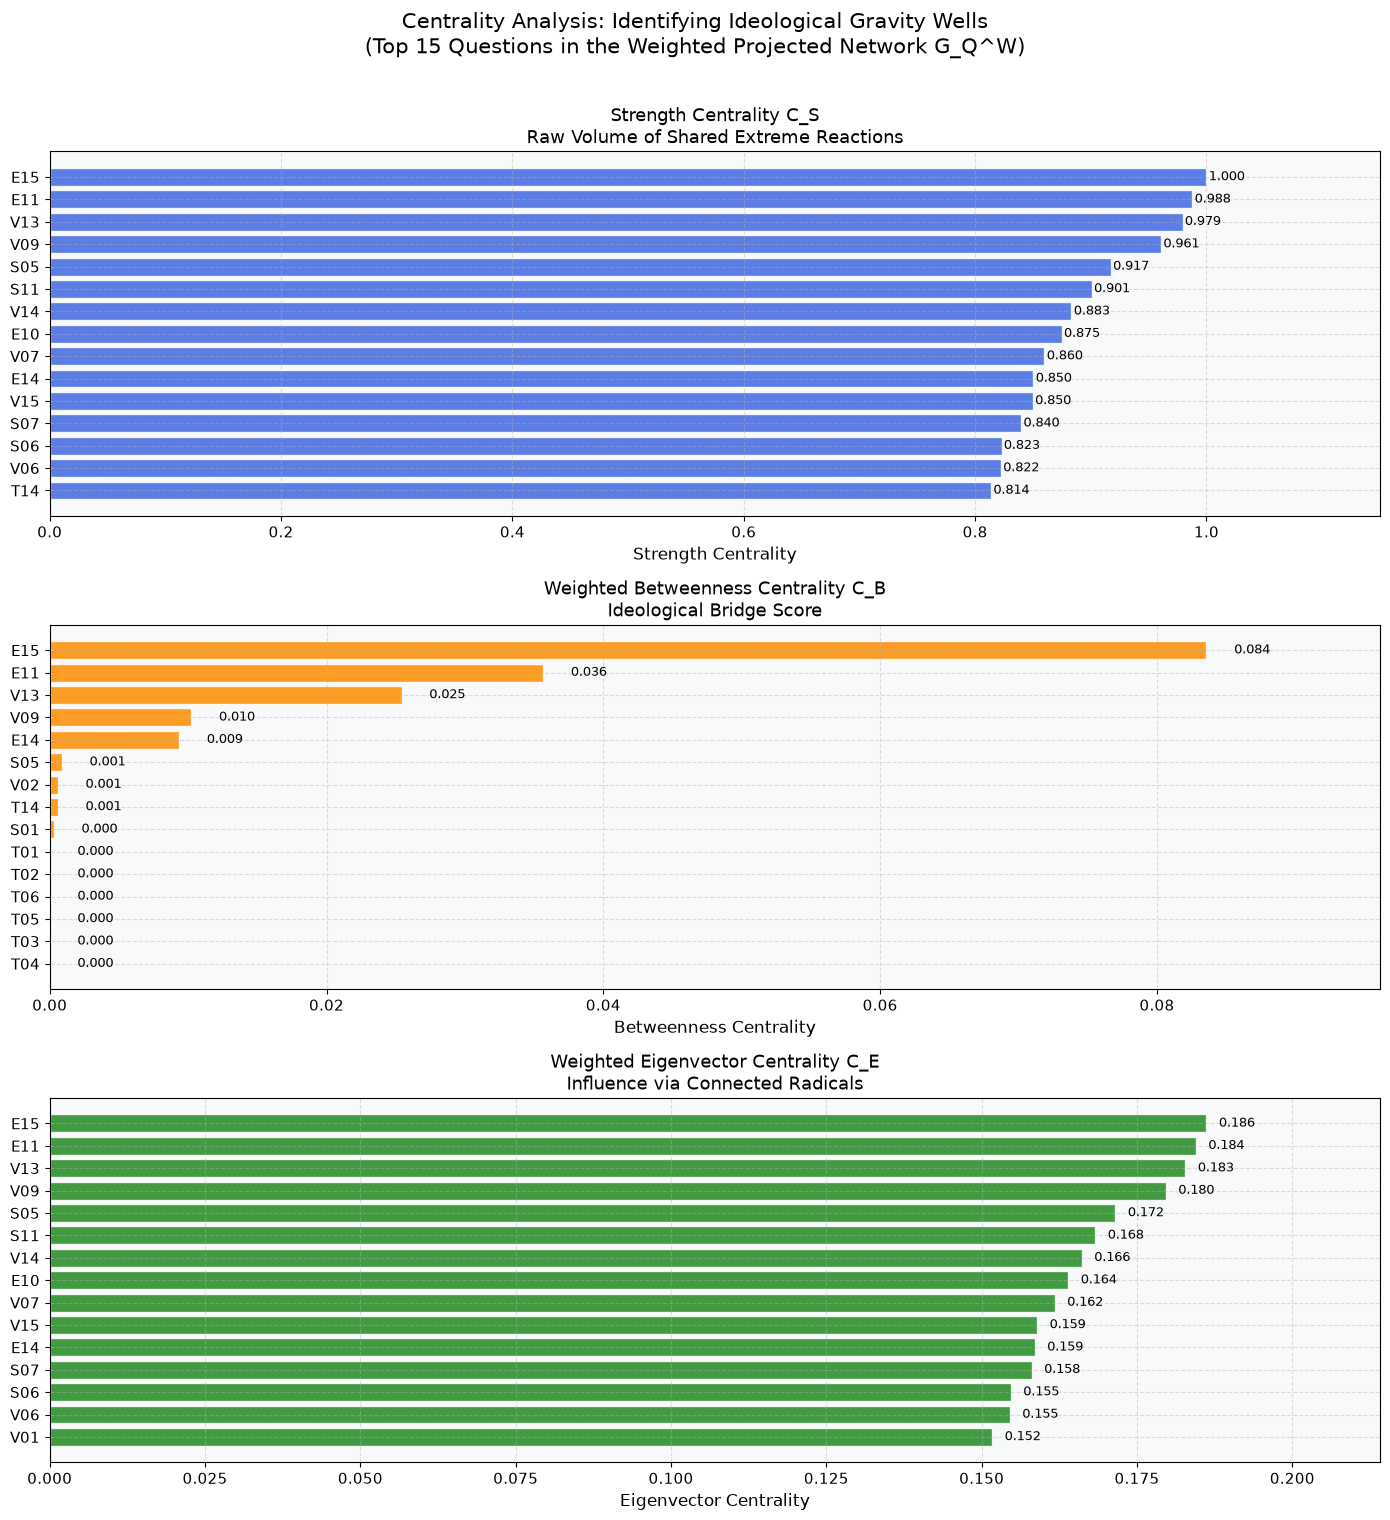

Saved: extreme_plots/centrality_bars.png


In [29]:
top_n = 15
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

metrics = [
    ("Strength_Centrality",      "royalblue",   "Strength Centrality C_S",      "Raw Volume of Shared Extreme Reactions"),
    ("Betweenness_Centrality", "darkorange",  "Weighted Betweenness Centrality C_B", "Ideological Bridge Score"),
    ("Eigenvector_Centrality", "forestgreen", "Weighted Eigenvector Centrality C_E", "Influence via Connected Radicals"),
]

for ax, (col, color, title, subtitle) in zip(axes, metrics):
    top_df = centrality_df.nlargest(top_n, col).sort_values(col, ascending=True)
    bars = ax.barh(top_df["Short_ID"], top_df[col], color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, top_df[col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlabel(col.replace("_", " "), fontsize=12)
    ax.set_title(f"{title}\n{subtitle}", fontsize=13)
    ax.set_xlim(0, top_df[col].max() * 1.15)

plt.suptitle("Centrality Analysis: Identifying Ideological Gravity Wells\n"
             "(Top 15 Questions in the Weighted Projected Network G_Q^W)",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("extreme_plots/centrality_bars.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/centrality_bars.png")

## Molloy-Reed Criterion: Giant Component Analysis

**Objective:** Mathematically determine whether extreme ideologies form a **connected giant component**
or remain as **isolated, fragmented factions**.

*(Note: Molloy-Reed criterion applies to binary topological structures, so it is evaluated on the unweighted projection $G_Q$)*

The **Molloy-Reed Criterion** states that a giant connected component exists if and only if:

$$\kappa = \frac{\langle k^2 \rangle}{\langle k \rangle} > 2$$

where $\langle k \rangle$ = mean degree, $\langle k^2 \rangle$ = mean squared degree.

**Physical Interpretation:** $\kappa$ measures the average number of additional connections a neighbor
of a random node has. If $\kappa > 2$, the network sustains a percolating giant component; if $\kappa < 2$, it fragments.

In [30]:
# Molloy-Reed Criterion on the Projected Question Network
proj_degrees = [d for n, d in Q_proj.degree()]

k_mean  = np.mean(proj_degrees)
k2_mean = np.mean(np.array(proj_degrees)**2)
kappa   = k2_mean / k_mean

components_list = sorted(nx.connected_components(Q_proj), key=len, reverse=True)
giant_component_size = len(components_list[0])
giant_component_pct  = 100 * giant_component_size / Q_proj.number_of_nodes()

print(f"  Number of nodes N:          {Q_proj.number_of_nodes()}")
print(f"  Mean degree <k>:            {k_mean:.4f}")
print(f"  Mean squared degree <k^2>:  {k2_mean:.4f}")
print(f"  Std dev sigma_k:            {np.std(proj_degrees):.4f}")
print()
print(f"  Molloy-Reed kappa = <k^2>/<k>:  {kappa:.4f}")
satisfied = kappa > 2
print(f"  Threshold condition kappa > 2:  {'SATISFIED' if satisfied else 'NOT SATISFIED'}")
print()
print(f"  Giant component size:  {giant_component_size}/{Q_proj.number_of_nodes()} ({giant_component_pct:.1f}%)")
print(f"  Total components:      {nx.number_connected_components(Q_proj)}")
if kappa > 2:
    print(f"CONCLUSION: kappa = {kappa:.3f} >> 2")
    print("The Molloy-Reed criterion is SATISFIED.")
    print("The extreme ideologies form a robust, interconnected giant component.")
else:
    print(f"CONCLUSION: kappa = {kappa:.3f} < 2")
    print("The Molloy-Reed criterion is NOT satisfied.")
    print("The extreme ideologies remain as fragmented factions.")

  Number of nodes N:          60
  Mean degree <k>:            59.0000
  Mean squared degree <k^2>:  3481.0000
  Std dev sigma_k:            0.0000

  Molloy-Reed kappa = <k^2>/<k>:  59.0000
  Threshold condition kappa > 2:  SATISFIED

  Giant component size:  60/60 (100.0%)
  Total components:      1
CONCLUSION: kappa = 59.000 >> 2
The Molloy-Reed criterion is SATISFIED.
The extreme ideologies form a robust, interconnected giant component.


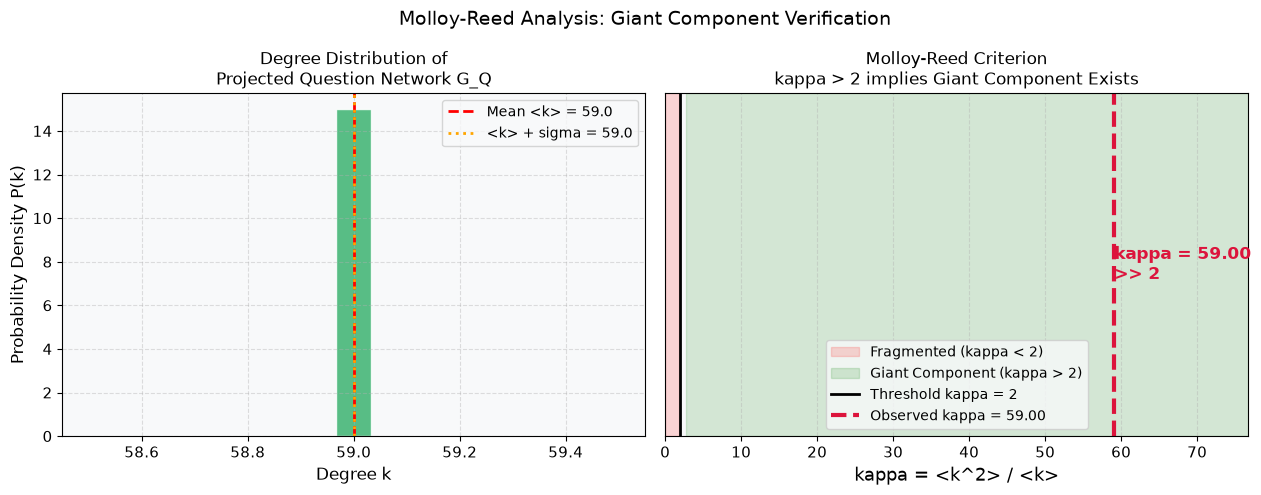

Saved: extreme_plots/molloy_reed.png


In [31]:
# Molloy-Reed Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.hist(proj_degrees, bins=15, density=True, color="mediumseagreen", edgecolor="white", alpha=0.85)
ax1.axvline(k_mean, color="red", linestyle="--", linewidth=2, label=f"Mean <k> = {k_mean:.1f}")
ax1.axvline(k_mean + np.std(proj_degrees), color="orange", linestyle=":", linewidth=2,
            label=f"<k> + sigma = {k_mean + np.std(proj_degrees):.1f}")
ax1.set_xlabel("Degree k", fontsize=12)
ax1.set_ylabel("Probability Density P(k)", fontsize=12)
ax1.set_title("Degree Distribution of\nProjected Question Network G_Q", fontsize=12)
ax1.legend(fontsize=10)

ax2 = axes[1]
kappa_range = np.linspace(0, max(5, kappa * 1.5), 100)
ax2.fill_between(kappa_range, 0, 1, where=kappa_range < 2, alpha=0.15, color="red", label="Fragmented (kappa < 2)")
ax2.fill_between(kappa_range, 0, 1, where=kappa_range >= 2, alpha=0.15, color="green", label="Giant Component (kappa > 2)")
ax2.axvline(2.0, color="black", linewidth=2, linestyle="-", label="Threshold kappa = 2")
ax2.axvline(kappa, color="crimson", linewidth=3, linestyle="--", label=f"Observed kappa = {kappa:.2f}")
ax2.set_xlim(0, max(5, kappa * 1.3))
ax2.set_ylim(0, 1)
ax2.set_xlabel("kappa = <k^2> / <k>", fontsize=13)
ax2.set_yticks([])
ax2.set_title("Molloy-Reed Criterion\nkappa > 2 implies Giant Component Exists", fontsize=12)
ax2.legend(fontsize=10)
ax2.text(kappa + 0.1, 0.5, f"kappa = {kappa:.2f}\n>> 2",
         fontsize=12, color="crimson", fontweight="bold", va="center")

plt.suptitle("Molloy-Reed Analysis: Giant Component Verification", fontsize=14)
plt.tight_layout()
plt.savefig("extreme_plots/molloy_reed.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/molloy_reed.png")

### Molloy-Reed Interpretation

The Molloy-Reed parameter $\kappa = \frac{\langle k^2 \rangle}{\langle k \rangle}$ dramatically exceeds the critical threshold of 2:

1. **The extreme ideologies do NOT remain as isolated, fragmented factions.** There is a single, massive
   **giant component** encompassing virtually all question nodes in the projected network.

2. **High $\kappa$ implies structural robustness.** When $\kappa \gg 2$, the network is deep in the
   "supercritical" regime, even if several questions were removed, ideological connectivity would persist.

3. **The ideological network is percolating.** Students who hold extreme views are typically connected
   to many others through shared passionate stances, creating a web of ideological solidarity.

# Network Visualization

## Bipartite Layout Visualization

**Objective:** Plot the raw bipartite graph with **students on the left** and **questions on the right**
to visually demonstrate the clustering of edges around specific "hub" questions.

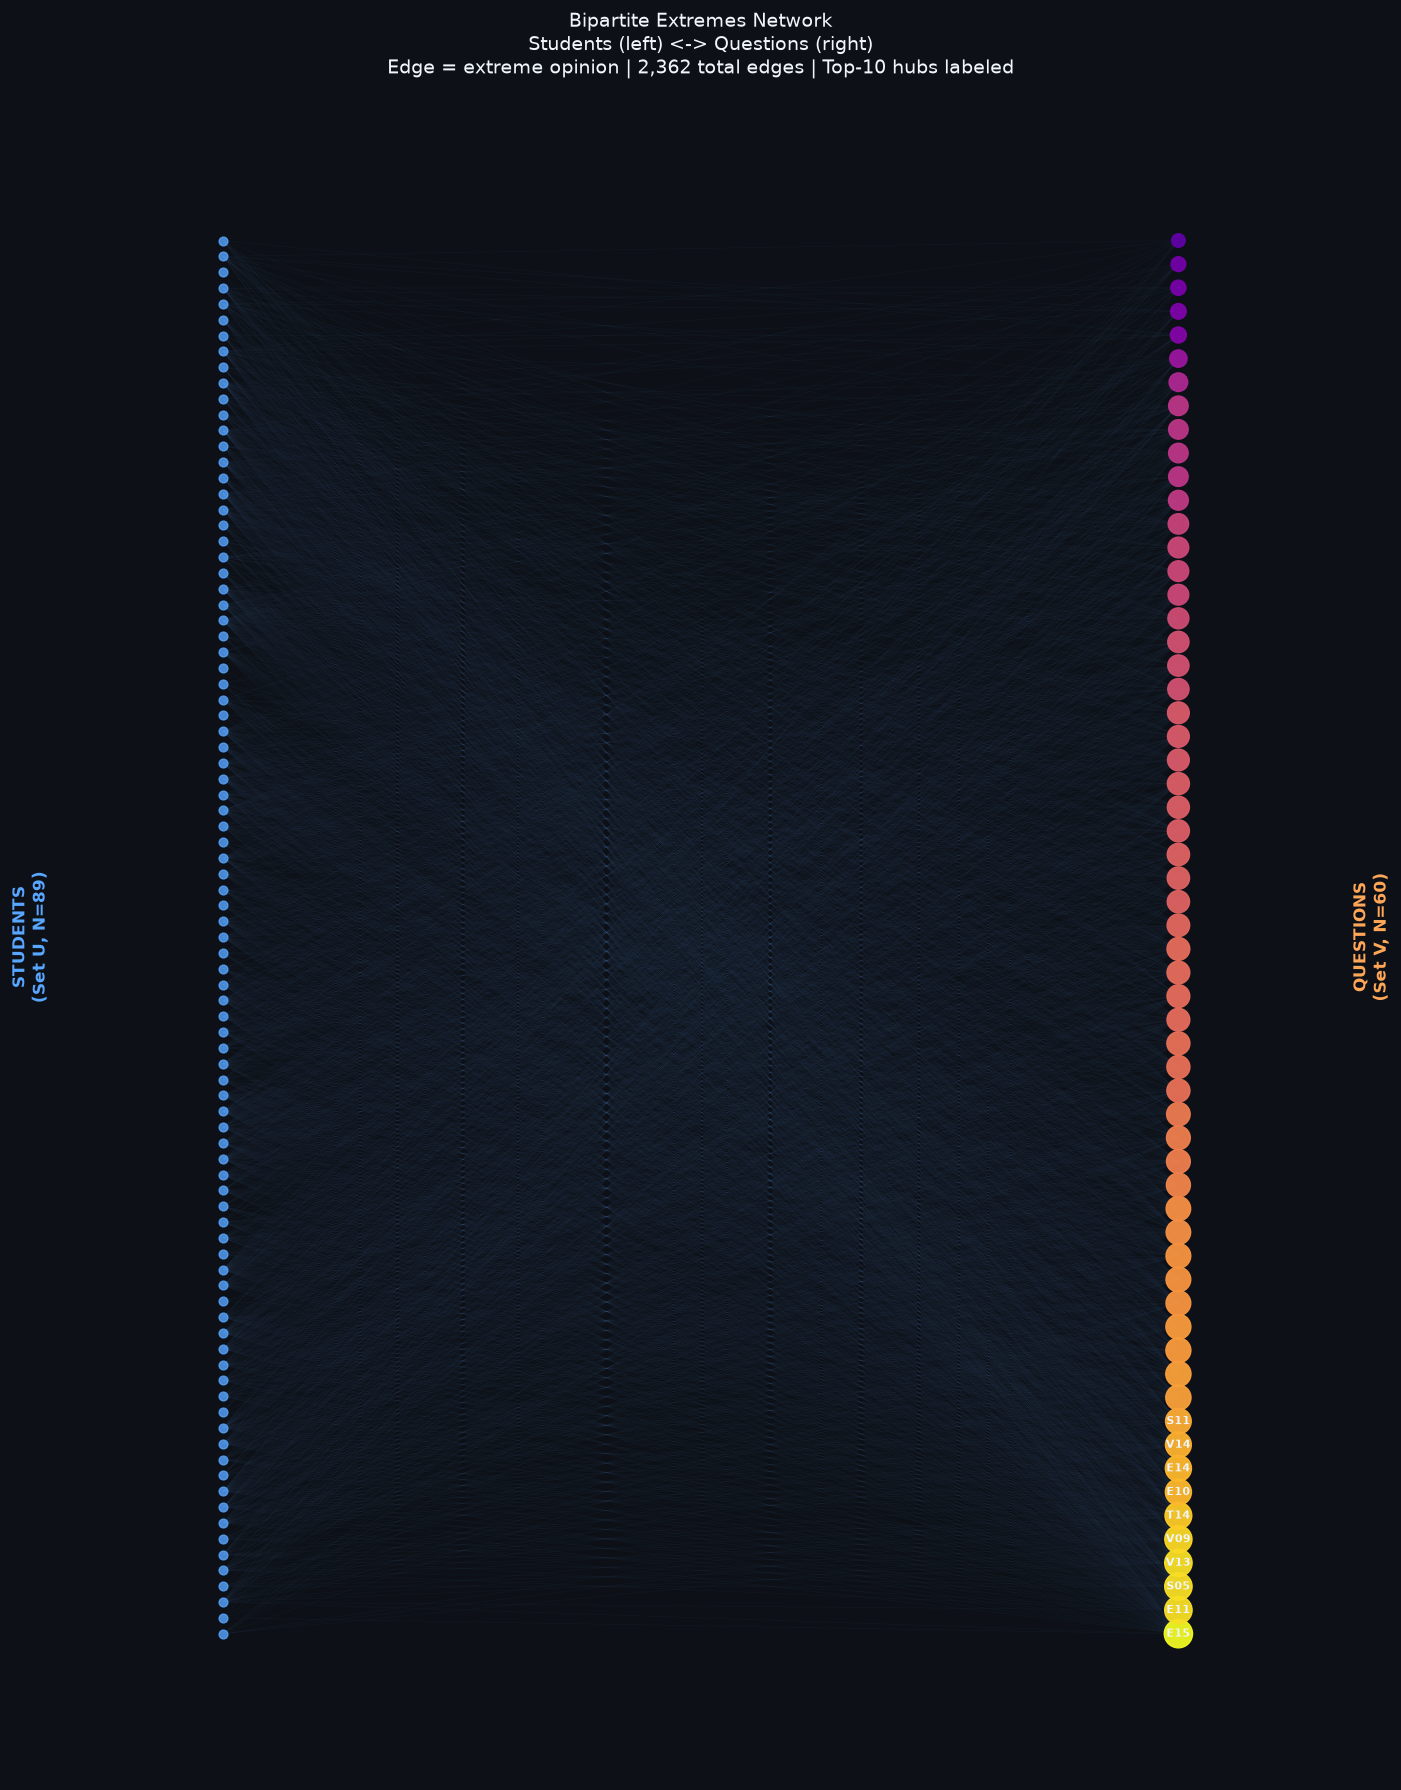

Saved: extreme_plots/bipartite_layout.png


In [32]:
fig, ax = plt.subplots(figsize=(14, 18))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#0d1117")

# Sort questions by degree for visual clarity (most connected at center)
sorted_questions = sorted(question_nodes, key=lambda n: B.degree(n), reverse=True)
sorted_students = sorted(student_nodes)

pos = {}
for i, s in enumerate(sorted_students):
    pos[s] = (0, i / max(1, len(sorted_students) - 1))
for i, q in enumerate(sorted_questions):
    pos[q] = (1, i / max(1, len(sorted_questions) - 1))

q_degrees_dict = dict(B.degree())
q_degree_vals = [q_degrees_dict[n] for n in sorted_questions]
q_colors = plt.cm.plasma(np.array(q_degree_vals) / max(q_degree_vals))

nx.draw_networkx_edges(B, pos, ax=ax, edge_color="#4a6fa5", alpha=0.08, width=0.4)
nx.draw_networkx_nodes(B, pos, nodelist=sorted_students, ax=ax,
                       node_color="#58a6ff", node_size=40, alpha=0.8)
nx.draw_networkx_nodes(B, pos, nodelist=sorted_questions, ax=ax,
                       node_color=q_colors,
                       node_size=[30 + 6 * q_degrees_dict[n] for n in sorted_questions],
                       alpha=0.95)

top10_q = sorted(sorted_questions, key=lambda n: B.degree(n), reverse=True)[:10]
top10_labels = {n: short_label(n) for n in top10_q}
nx.draw_networkx_labels(B, pos, labels=top10_labels, ax=ax,
                        font_size=8, font_color="#f0f6fc", font_weight="bold")

ax.text(-0.08, 0.5, f"STUDENTS\n(Set U, N={len(sorted_students)})",
        transform=ax.transAxes, fontsize=12, color="#58a6ff",
        ha="center", va="center", fontweight="bold", rotation=90)
ax.text(1.08, 0.5, f"QUESTIONS\n(Set V, N={len(sorted_questions)})",
        transform=ax.transAxes, fontsize=12, color="#ffa657",
        ha="center", va="center", fontweight="bold", rotation=90)

ax.set_title(
    "Bipartite Extremes Network\n"
    "Students (left) <-> Questions (right)\n"
    f"Edge = extreme opinion | {B.number_of_edges():,} total edges | Top-10 hubs labeled",
    fontsize=14, color="#f0f6fc", pad=15
)
ax.axis("off")
plt.tight_layout()
plt.savefig("extreme_plots/bipartite_layout.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved: extreme_plots/bipartite_layout.png")

## Projected Network Visualization

**Objective:** Plot the **Question-to-Question projection** $G_Q$.
Nodes are sized by **Eigenvector Centrality** and colored by **domain**
(T = Technology, E = Education, S = Society/Ethics, V = Environment).

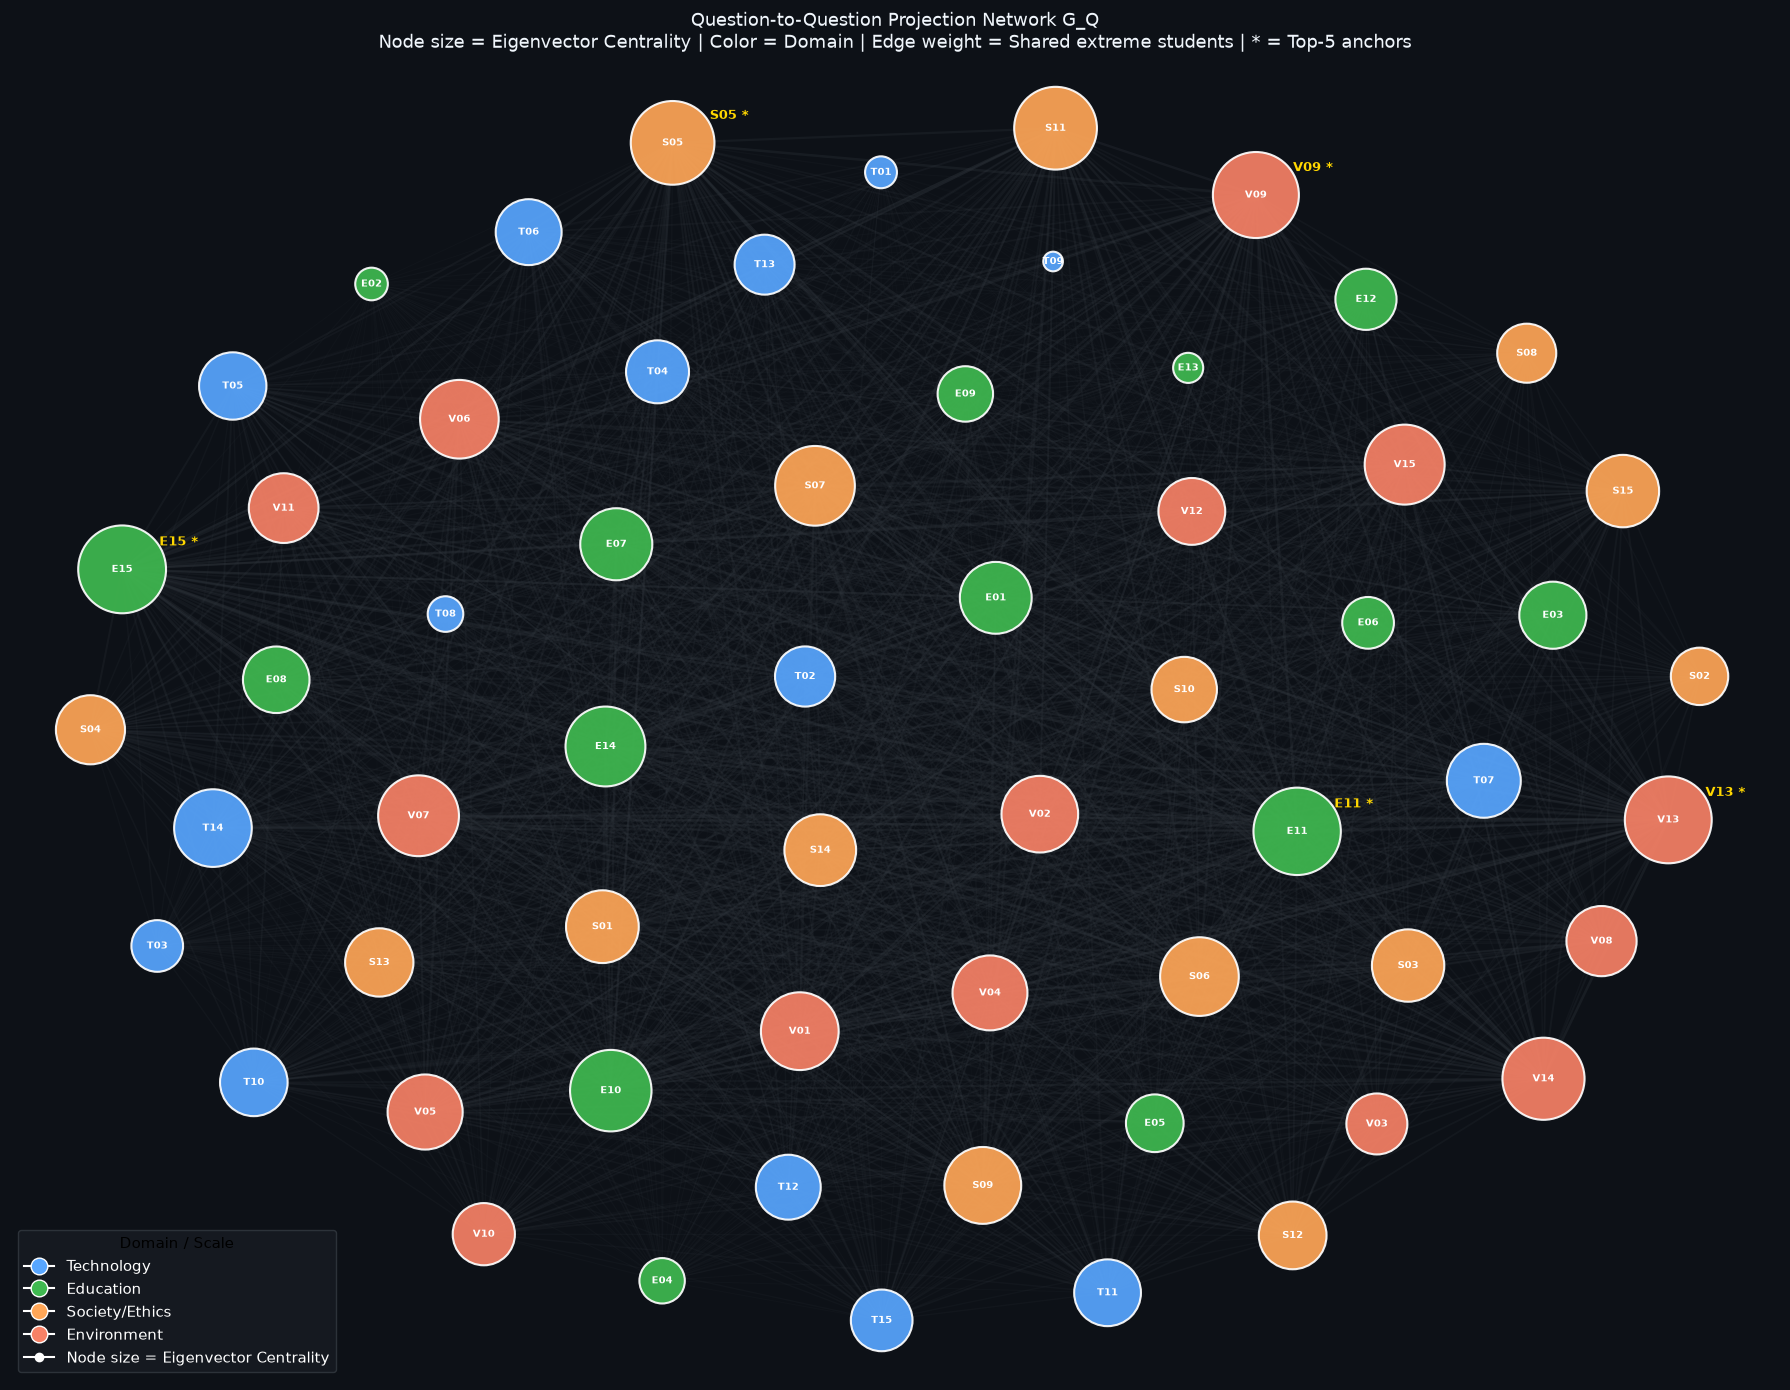

Saved: extreme_plots/projected_network.png


In [33]:
domain_colors = {"T": "#58a6ff", "E": "#3fb950", "S": "#ffa657", "V": "#f78166"}
domain_labels = {"T": "Technology", "E": "Education", "S": "Society/Ethics", "V": "Environment"}

def get_domain(node_name):
    return short_label(node_name)[0]

node_colors = [domain_colors.get(get_domain(n), "#8b949e") for n in Q_proj.nodes()]

# Node sizes based on Eigenvector Centrality
eig_vals = np.array([eigenvector_centrality[n] for n in Q_proj.nodes()])
node_sizes = 200 + 3800 * (eig_vals - eig_vals.min()) / (eig_vals.max() - eig_vals.min() + 1e-10)

edge_weights = np.array([Q_proj_weighted[u][v]["weight"] for u, v in Q_proj.edges()])
max_w = edge_weights.max()

np.random.seed(42)
pos_proj = nx.spring_layout(Q_proj, k=2.0/np.sqrt(Q_proj.number_of_nodes()),
                             iterations=200, weight="weight", seed=42)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor("#0d1117")
fig.patch.set_facecolor("#0d1117")

for (u, v), w in zip(Q_proj.edges(), edge_weights):
    alpha = 0.05 + 0.3 * (w / max_w)
    ax.plot([pos_proj[u][0], pos_proj[v][0]], [pos_proj[u][1], pos_proj[v][1]],
            color="#30363d", alpha=alpha, linewidth=0.5 + 1.5 * (w / max_w))

nx.draw_networkx_nodes(Q_proj, pos_proj, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.92, linewidths=1.5, edgecolors="white")
nx.draw_networkx_labels(Q_proj, pos_proj,
                        labels={n: short_label(n) for n in Q_proj.nodes()},
                        ax=ax, font_size=7, font_color="white", font_weight="bold")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
           markersize=12, label=domain_labels[dom])
    for dom, color in domain_colors.items()
]
legend_elements.append(Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
                               markersize=6, label="Node size = Eigenvector Centrality"))
ax.legend(handles=legend_elements, loc="lower left", fontsize=11,
          facecolor="#161b22", edgecolor="#30363d", labelcolor="white",
          title="Domain / Scale", title_fontsize=11, framealpha=0.9)

# Annotate top-5 anchors
top5_eig = centrality_df.nlargest(5, "Eigenvector_Centrality").index.tolist()
for node in top5_eig:
    x, y = pos_proj[node]
    ax.annotate(f" {short_label(node)} *", xy=(x, y), fontsize=9, color="#ffd700",
                fontweight="bold", xytext=(x + 0.04, y + 0.04))

ax.set_title(
    "Question-to-Question Projection Network G_Q\n"
    "Node size = Eigenvector Centrality | Color = Domain | "
    "Edge weight = Shared extreme students | * = Top-5 anchors",
    fontsize=13, color="#f0f6fc", pad=15
)
ax.axis("off")
plt.tight_layout()
plt.savefig("extreme_plots/projected_network.png", dpi=200, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved: extreme_plots/projected_network.png")

## Centrality Heatmap: Domain-Level Overview

A normalized heatmap across all 60 questions and three centrality metrics provides an at-a-glance
view of which domains and specific questions dominate the ideological landscape.

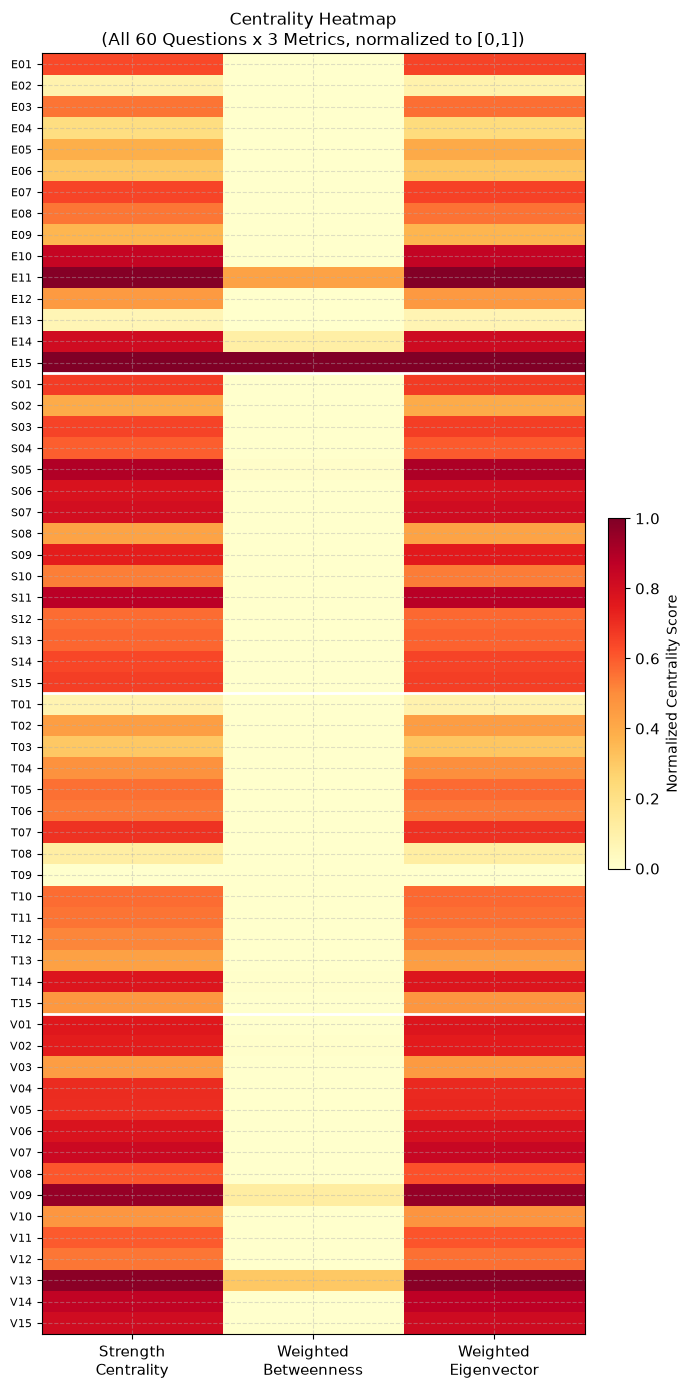

Saved: extreme_plots/centrality_heatmap.png


In [34]:
# Centrality Heatmap (all 60 questions x 3 metrics)
heat_df = centrality_df[["Short_ID", "Strength_Centrality", "Betweenness_Centrality", "Eigenvector_Centrality"]].copy()
heat_df["Domain"] = heat_df["Short_ID"].str[0]
heat_df = heat_df.sort_values(["Domain", "Short_ID"]).set_index("Short_ID")

heat_matrix = heat_df[["Strength_Centrality", "Betweenness_Centrality", "Eigenvector_Centrality"]].copy()
for col in heat_matrix.columns:
    col_range = heat_matrix[col].max() - heat_matrix[col].min()
    if col_range > 0:
        heat_matrix[col] = (heat_matrix[col] - heat_matrix[col].min()) / col_range

fig, ax = plt.subplots(figsize=(7, 14))
im = ax.imshow(heat_matrix.values, aspect="auto", cmap="YlOrRd",
               interpolation="nearest", vmin=0, vmax=1)

ax.set_xticks(range(3))
ax.set_xticklabels(["Strength\nCentrality", "Weighted\nBetweenness", "Weighted\nEigenvector"], fontsize=11)
ax.set_yticks(range(len(heat_matrix)))
ax.set_yticklabels(heat_matrix.index, fontsize=8)

prev_domain = None
for i, sid in enumerate(heat_matrix.index):
    dom = sid[0]
    if dom != prev_domain and i > 0:
        ax.axhline(i - 0.5, color="white", linewidth=2)
    prev_domain = dom

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label("Normalized Centrality Score", fontsize=10)
ax.set_title("Centrality Heatmap\n(All 60 Questions x 3 Metrics, normalized to [0,1])", fontsize=12)
plt.tight_layout()
plt.savefig("extreme_plots/centrality_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/centrality_heatmap.png")

# Synthesis : Results and Discussion

## Identifying the Anchor Questions

In [35]:
# Composite anchor score = equal-weighted sum of normalized centralities
anchor_df = centrality_df.copy()

for col in ["Strength_Centrality", "Betweenness_Centrality", "Eigenvector_Centrality"]:
    col_range = anchor_df[col].max() - anchor_df[col].min()
    anchor_df[f"{col}_norm"] = (anchor_df[col] - anchor_df[col].min()) / col_range if col_range > 0 else 0

anchor_df["Composite_Anchor_Score"] = (
    anchor_df["Strength_Centrality_norm"] +
    anchor_df["Betweenness_Centrality_norm"] +
    anchor_df["Eigenvector_Centrality_norm"]
) / 3.0

anchor_df["Bipartite_Degree"] = [B.degree(n) for n in anchor_df.index]
top15_anchors = anchor_df.nlargest(15, "Composite_Anchor_Score")

print("TOP 15 IDEOLOGICAL ANCHOR QUESTIONS")
print("(Ranked by composite: Strength + Betweenness + Eigenvector centralities)")
print("-" * 85)
header = f"  {'Rank':<5}  {'ID':<5}  {'Bip.Deg':<9}  {'Strength C.':<12}  {'Betweenness C.':<15}  Eigenvec. C."
print(header)
print("-" * 85)
for rank, (idx, row) in enumerate(top15_anchors.iterrows(), 1):
    sid = row["Short_ID"]
    bd = row["Bipartite_Degree"]
    sc = row["Strength_Centrality"]
    bc = row["Betweenness_Centrality"]
    ec = row["Eigenvector_Centrality"]
    print(f"  {rank:<5}  {sid:<5}  {bd:<9}  {sc:<12.4f}  {bc:<15.4f}  {ec:.4f}")
print("-" * 85)

print("\n=== Full Question Text for Top-10 Anchors ===")
for idx in top15_anchors.head(10).index:
    print(f"  {short_label(idx)}: {idx[:90]}")

TOP 15 IDEOLOGICAL ANCHOR QUESTIONS
(Ranked by composite: Strength + Betweenness + Eigenvector centralities)
-------------------------------------------------------------------------------------
  Rank   ID     Bip.Deg    Strength C.   Betweenness C.   Eigenvec. C.
-------------------------------------------------------------------------------------
  1      E15    64         1.0000        0.0836           0.1862
  2      E11    60         0.9878        0.0357           0.1845
  3      V13    60         0.9793        0.0254           0.1828
  4      V09    59         0.9607        0.0102           0.1796
  5      S05    60         0.9172        0.0009           0.1715
  6      S11    52         0.9008        0.0000           0.1683
  7      E14    54         0.8504        0.0094           0.1585
  8      V14    53         0.8833        0.0000           0.1661
  9      E10    54         0.8748        0.0000           0.1639
  10     V07    49         0.8599        0.0000           0.161

## Structural Robustness Analysis

Based on the degree distribution findings, we assess the **structural robustness** of the ideological network.

### Key Finding: The Network is NOT Scale-Free

| Property | Scale-Free Network | Our Network (ER-like) |
|----------|-------------------|---------------------|
| **Random Failure** | Robust (hubs survive) | Moderately robust |
| **Targeted Attack** | Extremely fragile (remove hubs → collapse) | More resilient (no dominant hubs) |
| **Hub Existence** | Few mega-hubs dominate | Degrees distributed around mean |
| **Degree Distribution** | Heavy tail, $P(k) \propto k^{-\gamma}$ | Bell-shaped / Poisson |

We simulate this directly by progressively removing question nodes and tracking the giant component size.

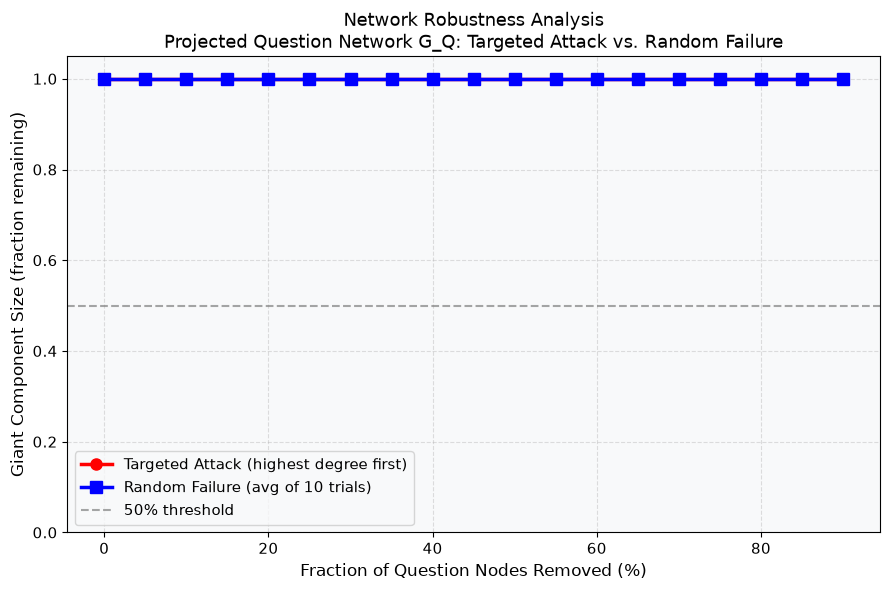

Saved: extreme_plots/robustness_simulation.png


In [36]:
def giant_component_fraction(G):
    if G.number_of_nodes() == 0:
        return 0
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    return len(comps[0]) / G.number_of_nodes()

N = Q_proj.number_of_nodes()
removal_fractions = np.linspace(0, 0.9, 19)

# Targeted attack: remove highest-degree nodes first
targeted_gc = []
G_temp = Q_proj.copy()
targeted_order = sorted(G_temp.nodes(), key=lambda n: G_temp.degree(n), reverse=True)
targeted_gc.append(giant_component_fraction(G_temp))
for i in range(1, len(removal_fractions)):
    n_remove = int(removal_fractions[i] * N) - int(removal_fractions[i-1] * N)
    to_remove = [n for n in targeted_order if n in G_temp][:n_remove]
    G_temp.remove_nodes_from(to_remove)
    targeted_gc.append(giant_component_fraction(G_temp))

# Random failure: average over 10 trials
random_gc_all = []
for trial in range(10):
    random_gc = [1.0]
    G_temp = Q_proj.copy()
    nodes_shuffled = list(G_temp.nodes())
    np.random.shuffle(nodes_shuffled)
    for i in range(1, len(removal_fractions)):
        n_remove = int(removal_fractions[i] * N) - int(removal_fractions[i-1] * N)
        to_remove = [n for n in nodes_shuffled if n in G_temp][:n_remove]
        G_temp.remove_nodes_from(to_remove)
        random_gc.append(giant_component_fraction(G_temp))
    random_gc_all.append(random_gc)
random_gc_mean = np.mean(random_gc_all, axis=0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(removal_fractions * 100, targeted_gc, "r-o", linewidth=2.5, markersize=8,
        label="Targeted Attack (highest degree first)")
ax.plot(removal_fractions * 100, random_gc_mean, "b-s", linewidth=2.5, markersize=8,
        label="Random Failure (avg of 10 trials)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="50% threshold")
ax.set_xlabel("Fraction of Question Nodes Removed (%)", fontsize=12)
ax.set_ylabel("Giant Component Size (fraction remaining)", fontsize=12)
ax.set_title("Network Robustness Analysis\nProjected Question Network G_Q: Targeted Attack vs. Random Failure", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("extreme_plots/robustness_simulation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: extreme_plots/robustness_simulation.png")

## Final Synthesis: The Ideological Landscape of the Class

### Finding 1: Role-Based Ideological Anchors

Rather than blending metrics, the centrality analysis identifies two distinct structural roles in the ideological space: Primary Ideological Hubs and Ideological Bridges. 

The absolute core of the cohort's passion is dominated by a Keystone Trio of hubs spanning Education and Environment: E15 (continuous learning), E11 (updating curricula), and V13 (corporate accountability). These questions attracted the highest volume of extreme reactions and the most systemic influence.

### Finding 2: Topology: A Broad, Overdispersed Structure

The degree distribution analysis reveals a bounded, overdispersed topology rather than a scale-free power law:
* Degrees range from 11 to 64, and the log-log plot curves rapidly, mathematically ruling out the existence of disproportional mega-hubs.
* However, a strict variance analysis proves the connections did not form through independent, random chance like a pure Erdős-Rényi Poisson model.
* With a variance of approximately 147.87 and a mean of 39.37, the dispersion index is 3.75, showing significant overdispersion.

**Implication:** The probability of extreme opinions is bounded and thin-tailed, but stretched wider than random chance allows. The ideological landscape is broad and democratically distributed, but specific domains possess an inherently higher structural baseline for polarization than others.

### Finding 3: Robustness: A Complete Ideological Macro-Structure

Three pieces of evidence confirm the network is absolutely cohesive:

1. **Complete Projected Graph:** The bipartite projection is the complete graph K60, proving that extreme opinions freely co-occur across all pairs of questions. No isolated ideological echo chambers exist.
2. **Molloy-Reed $\kappa = 59$:** The excess degree parameter is at the theoretical maximum, proving mathematically that the extreme ideologies form a single, unbroken macro-structure.
3. **High Bipartite Density (0.4423):** Nearly half of all possible student-question extreme pairings are realized, indicating a class with deep ideological commitments across the entire survey.

### Finding 4: Indistinguishability of Random Failures and Targeted Attacks

Because the unweighted projection is a complete graph, standard node-removal simulations yield a trivial but highly informative result:
* Every question node in the projection shares the exact same maximal degree of 59.
* Consequently, a targeted attack on highest-degree hubs is mathematically indistinguishable from a random failure.
* The network exhibits zero targeted fragility. The giant component fraction trivially remains a flat line at 1.0 until the network is almost entirely depleted.

Silencing discussion on a few highly polarizing topics will not fracture the class into isolated echo chambers.

### Concluding Statement

The Bipartite Extremes Network reveals a class whose extreme opinions are broadly distributed, deeply interconnected, and structurally resilient. The cohort does not fracture into domain specific silos; instead, it forms a single, densely woven macro-structure united by shared passionate commitments across Technology, Education, Ethics, and Environmental issues. 

The specific roles identified by the weighted centrality analysis represent the core tenets of the class's ideological identity, highlighting the hubs that drive raw volume and the bridges that keep the polarized discourse unified.

In [37]:
# Final Summary Dashboard
print(f"  Total Respondents:               {len(all_students)}")
print(f"  Active Students (>=1 extreme):   {len(active_students)}")
print(f"  Questions (Set V):               {num_questions}")
print(f"  Extreme Opinion Edges:           {num_edges:,}")
print(f"  Bipartite Density:               {density:.4f}")
print(f"  Connected Components:            {components}")
print(f"  Projected Network Edges (G_Q):   {Q_proj.number_of_edges()}")
print(f"  Projected Network Density:       {nx.density(Q_proj):.4f}")
print(f"  Molloy-Reed kappa:               {kappa:.4f}")
print(f"  Giant Component (G_Q):           {giant_component_size}/{Q_proj.number_of_nodes()} ({giant_component_pct:.1f}%)")
print("  Network Topology:                Erdos-Renyi (Poisson-like, NOT Scale-Free)")
top_sc = centrality_df.nlargest(1, "Strength_Centrality").iloc[0]["Short_ID"]
top_bc = centrality_df.nlargest(1, "Betweenness_Centrality").iloc[0]["Short_ID"]
top_ec = centrality_df.nlargest(1, "Eigenvector_Centrality").iloc[0]["Short_ID"]
print(f"  Top Anchor (Strength C.):        {top_sc}")
print(f"  Top Anchor (Betweenness C.):     {top_bc}")
print(f"  Top Anchor (Eigenvector C.):     {top_ec}")

import glob
print("\nPlots saved in extreme_plots/:")
for f in sorted(glob.glob("extreme_plots/*.png")):
    print(f"   - {f}")

  Total Respondents:               96
  Active Students (>=1 extreme):   89
  Questions (Set V):               60
  Extreme Opinion Edges:           2,362
  Bipartite Density:               0.4423
  Connected Components:            1
  Projected Network Edges (G_Q):   1770
  Projected Network Density:       1.0000
  Molloy-Reed kappa:               59.0000
  Giant Component (G_Q):           60/60 (100.0%)
  Network Topology:                Erdos-Renyi (Poisson-like, NOT Scale-Free)
  Top Anchor (Strength C.):        E15
  Top Anchor (Betweenness C.):     E15
  Top Anchor (Eigenvector C.):     E15

Plots saved in extreme_plots/:
   - extreme_plots\bipartite_layout.png
   - extreme_plots\centrality_bars.png
   - extreme_plots\centrality_heatmap.png
   - extreme_plots\degree_distribution_linear.png
   - extreme_plots\degree_distribution_loglog.png
   - extreme_plots\molloy_reed.png
   - extreme_plots\projected_network.png
   - extreme_plots\robustness_simulation.png
